# ANÁLISIS DE LA PREDICCIÓN DE ICTUS

In [70]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import bootcampviztools as bt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

%matplotlib inline

In [2]:
# Cargamos el df para visualizarlo:
df_stroke_prediction = pd.read_csv("src/data/healthcare-dataset-stroke-data.csv")
df_stroke_prediction.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [3]:
# Obtenemos más información:
df_stroke_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Dataset:** healthcare-dataset-stroke-data.csv  
**Descripción:** Datos de 5110 personas distintas, distinguiendo entre su ID, sexo, edad, tipo de trabajo
y residencia, si están casados, fuman, tienen hipertensión, enfermedad cardiaca, han tenido ictus, o 
nivel de glucosa y BMI.  
**Periodo:**  No especifica.


| Nombre del campo | Descripción                                      | Tipo de variable | Importancia Inicial | Notas |
|------------------|--------------------------------------------------|------------------|---------------------|-------|
| id               | id de cada persona                               | Índice único     |            -        |       |
| gender           | sexo femenino/masculino                          | Binaria          |          2          |       |
| age              | edad de la persona                               | Numérica discreta|        1            | Hay menores de 18 y adultos, senior =+65|
| hypertension     | si tiene hipertensión o no                       | Binaria          |        1            |       |
| heart_disease    | si tiene una cardiopatía o no                    | Binaria          |           1         |       |
| ever_married     | si están casados o no                            | Binaria          |           3         |       |
| work_type        | tipo de trabajo                                  | Categórica       |           3         |       |
| residence_type   | tipo de residencia                               | Binaria          |           3         |       |
| avg_glucose_level| valor promedio de glucosa                        | Numérica continua|          1          |       |
| bmi              | (Body Mass Index) - IMC, índice de Masa Corporal | Numérica discreta|            1        | bivariante - con stroke   |
| smoking_status   | si fuma o no                                     | Categórica       |          1          | multivariante      |
| stroke           | si ha tenido ictus o no                          | Binaria          |           0         | |



### Selección y limpieza del dataset ###

A partir de la información general del dataset, vamos a clasificar las variables según su cardinalidad. A partir de ello, vemos que la columna *bmi* tiene valores faltantes. Para tratarlos, es conveniente usar la **media**, ya que es una variable del tipo numérica discreta. Además, la variable **age** tiene valores decimales, con lo que es conveniente que sea un número entero, teniendo en cuenta que la edad de valor 0 son bebés entre 0 y 11 meses. 

In [4]:
# Buscamos la cardinalidad de las variables para clasificarlas:

df_tipos_variables = pd.DataFrame([df_stroke_prediction.nunique(), df_stroke_prediction.nunique()/len(df_stroke_prediction) * 100, df_stroke_prediction.dtypes]).T.rename(columns = {0: "Card",\
                                                                                                                                 1: "%_Card", 2: "Tipo"})
df_tipos_variables

,Card,%_Card,Tipo
id,5110,100.0,int64
gender,3,0.058708,object
age,104,2.035225,float64
hypertension,2,0.039139,int64
heart_disease,2,0.039139,int64
ever_married,2,0.039139,object
work_type,5,0.097847,object
Residence_type,2,0.039139,object
avg_glucose_level,3979,77.866928,float64
bmi,418,8.180039,float64


In [5]:
# Las clasificamos:

df_tipos_variables["Clasificada_como"] = "Categorica" 
df_tipos_variables.loc[df_tipos_variables.Card == 2, "Clasificada_como"] = "Binaria"
df_tipos_variables.loc[df_tipos_variables["Card"] > 10, "Clasificada_como"] ="Numerica Discreta"
df_tipos_variables.loc[df_tipos_variables["%_Card"] > 30, "Clasificada_como"] = "Numerica Continua"
df_tipos_variables

,Card,%_Card,Tipo,Clasificada_como
id,5110,100.0,int64,Numerica Continua
gender,3,0.058708,object,Categorica
age,104,2.035225,float64,Numerica Discreta
hypertension,2,0.039139,int64,Binaria
heart_disease,2,0.039139,int64,Binaria
ever_married,2,0.039139,object,Binaria
work_type,5,0.097847,object,Categorica
Residence_type,2,0.039139,object,Binaria
avg_glucose_level,3979,77.866928,float64,Numerica Continua
bmi,418,8.180039,float64,Numerica Discreta


In [6]:
df_stroke_prediction.info()
# Solamente hay una columna con null: bmi
# bmi es una variable tipo numérica discreta


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
# buscamos los null:
df_stroke_prediction["bmi"].value_counts(dropna=False)
# hay 201 valores con null

bmi
NaN     201
28.7     41
28.4     38
27.6     37
26.1     37
       ... 
47.9      1
13.0      1
46.3      1
54.1      1
14.9      1
Name: count, Length: 419, dtype: int64

In [8]:
# Vamos a confirmar los null en la columna bmi:
df_stroke_prediction.loc[df_stroke_prediction["bmi"].isna()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [9]:
# y ahora vamos a buscar la media de bmi para sustituir los null por la media, ya que es una variable del tipo numérica discreta:

df_stroke = df_stroke_prediction.copy()
bmi_mean = df_stroke["bmi"].mean().round(1)

# y la media es 28.9
# y como hemos cambiado valores, hicimos copia de nuestro df, y de aquí en adelante es solamente df_stroke

In [10]:
# y sustituimos los null por la media:
df_stroke.loc[df_stroke["bmi"].isna(), "bmi"] = bmi_mean
df_stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.9,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.9,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [11]:
# Revisamos la columna age, porque es decimal debido a que entre 0 y 11 meses miden la edad del bebé.
df_stroke["age"].describe() 

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [12]:
# hay 43 bebés entre 0 y 1 meses
df_stroke["age"].value_counts().sort_index() 


age
0.08       2
0.16       3
0.24       5
0.32       5
0.40       2
        ... 
78.00    102
79.00     85
80.00     70
81.00     60
82.00     56
Name: count, Length: 104, dtype: int64

In [13]:
# La columna age es float, podría ser int: 
df_stroke["age"] = df_stroke["age"].astype(int)

In [14]:
# aqui, el valor de age ya no es decimal, es directamente 0 para los bebés entre 0 y 11 meses
df_stroke["age"].describe()

count    5110.000000
mean       43.215264
std        22.633866
min         0.000000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [15]:
# y confirmamos que ya no tenemos null en bmi, y que age es int:
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int64  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 479.2+ KB


In [16]:
df_stroke["smoking_status"].value_counts(normalize=True) *100
# Los valores de Unknown representan poco más del 30% 
# No podemos despreciarlos pero tampoco sustituirlo por otro valor, debe ser tratado como si mismo
# podemos valorarlos por separado, entre los valores conocidos y los valores desconocidos
# y a su vez, compararlos con edad, sexo, bmi ... 

smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64

In [17]:
df_stroke["smoking_status"].value_counts() # vemos el número de valores que tiene Unknown

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [18]:
# Revisando, vemos que la columna gender tiene 3 tipos de elementos:
df_stroke["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [19]:
# Buscamos la moda y sustituimos ese Other por el valor de moda (por ser variable categórica nominal) para tener solamente 2 valores, male y female, y poder utilizar mejor esta variable:
gender_mode = df_stroke["gender"].mode()[0]
df_stroke.loc[df_stroke["gender"] == "Other", "gender"] = gender_mode
df_stroke["gender"].value_counts()


gender
Female    2995
Male      2115
Name: count, dtype: int64

In [20]:
# Veremos también la cantidad de personas de este estudio que han sufrido ictus, ya que son a quienes estudiaremos:

df_stroke["stroke"].value_counts(normalize=True) *100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [21]:
# son 249 personas quienes han sufrido ictus
df_stroke["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [22]:
# por último, borramos la columa id ya que no aporta valor al estudio y no es relevante en la prueba de nuestra hipótesis. 
# Tiene valores dispares y no sigue un orden:
df_stroke["id"].describe() 

count     5110.000000
mean     36517.829354
std      21161.721625
min         67.000000
25%      17741.250000
50%      36932.000000
75%      54682.000000
max      72940.000000
Name: id, dtype: float64

In [23]:
df_stroke = df_stroke.drop(columns=["id"])
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   int64  
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 439.3+ KB


## Preparación del dataset ##

- Tenemos finalmente 11 columnas, de las cuales usaremos las variables con una importancia entre 0 y 2, siendo la más importante la variable ***stroke***, en la que centraremos nuestro análisis para estudiar las personas que han sufrido o no ictus, y ver si se cumple la hipótesis planteada. De las personas que han sufrido un ictus, tenemos que son aproximadamente el 5% de personas estudiadas en este dataset, un total de 249 personas. 
- Rellenamos los valores *null* de la columna *bmi* con la media, que es 28.9.
- Cambiamos el tipo de dato de la variable *age* de *float* a *int*, y ahora los bebés de edad 0 corresponden a bebés entre 0 y 11 meses.
- En la columna *smoking_status* hay un 30% de valores *Unknown* que se tratarán con ese mismo valor, como desconocidos, al ser un valor muy alto como para sustituirlo por la mediana o moda.
- Cambiamos en la columna *gender* el valor encontrado de *Other* (solamente 1 valor), para tratar esta variable con valores de *Male* y *Female*
- Eliminamos la columna *id* al no encontrar relevancia para nuestro estudio, ya que solo es un identificador.
 

## ANÁLISIS UNIVARIANTE ##

### Variables categóricas ###

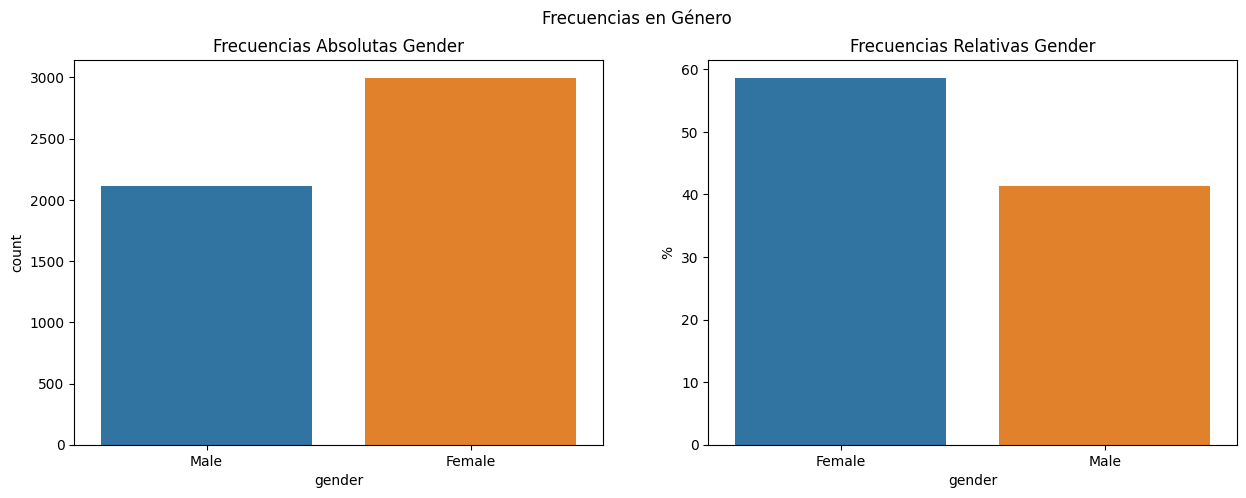

In [24]:
# Barras variable gender:
fig,axs = plt.subplots(nrows=1,ncols=2, figsize=(15,5))
fig.suptitle("Frecuencias en Género");
sns.countplot(x="gender", data = df_stroke, ax = axs[0], hue = "gender", legend =False)
axs[0].set_title("Frecuencias Absolutas Gender")

valores = df_stroke.gender.value_counts(normalize = True) * 100
sns.barplot(x = valores.index, y = valores.values, hue = valores.index, ax = axs[1])
axs[1].set_title("Frecuencias Relativas Gender")
axs[1].set_ylabel("%")
plt.show()

fig.savefig("src/img/univariante_gender_barras.png")


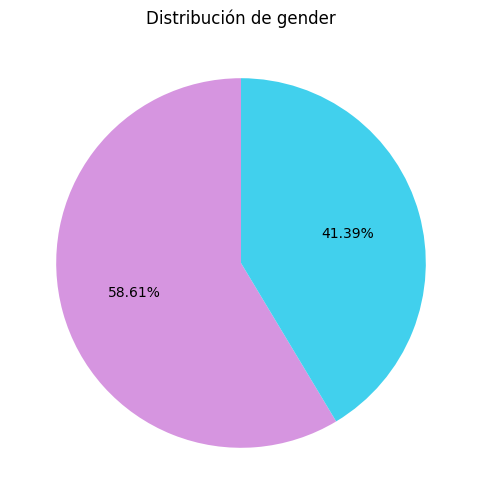

In [25]:
# tarta variable gender:
data = df_stroke["gender"].value_counts()
fig,ax = plt.subplots(1,1,figsize = (6,6))
colors = ["#D695E0", "#41D0ED"]
ax.pie(data.values,
        autopct='%.2f%%', 
        startangle= 90,
        colors=colors)
ax.set_title("Distribución de gender")
plt.show();

fig.savefig("src/img/univariante_gender_tarta.png")

Variable *age*:
- El estudio tiene cerca del 58% de personas del sexo femenino, y 42% del sexo masculino.


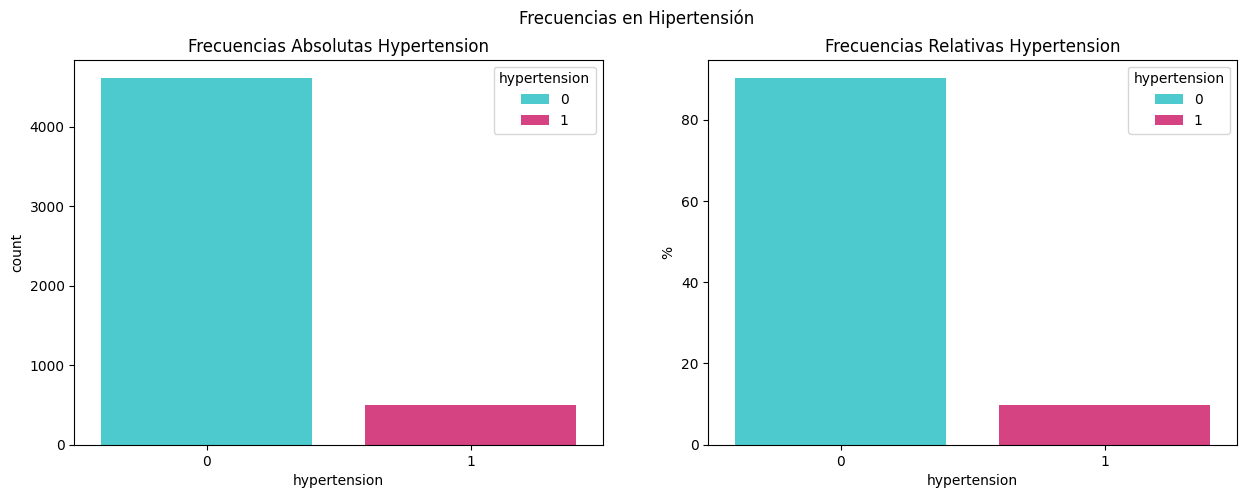

In [26]:
# Barras variable hypertension:
fig,axs = plt.subplots(nrows=1,ncols=2, figsize=(15,5))
fig.suptitle("Frecuencias en Hipertensión");
palette = ["#36DEE4", "#EF2A7F"]
sns.countplot(x="hypertension", data = df_stroke, ax = axs[0], hue = "hypertension", legend = True, palette= palette)
axs[0].set_title("Frecuencias Absolutas Hypertension")

valores = df_stroke.hypertension.value_counts(normalize = True) * 100
sns.barplot(x = valores.index, y = valores.values, hue = valores.index, ax = axs[1], palette=palette)
axs[1].set_title("Frecuencias Relativas Hypertension")
axs[1].set_ylabel("%")
plt.show();

fig.savefig("src/img/univariante_hypertension_barra.png")

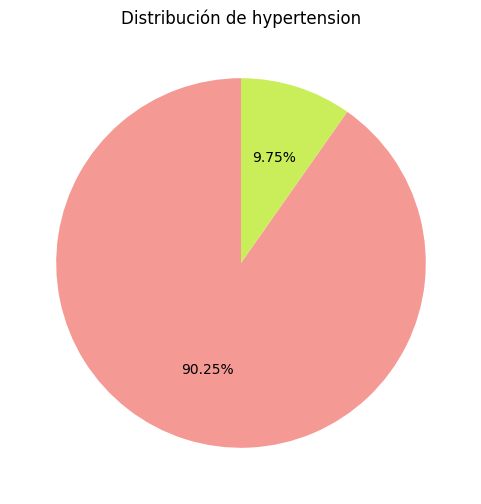

In [27]:
# tarta variable hypertension:
data = df_stroke["hypertension"].value_counts()
fig,ax = plt.subplots(1,1,figsize = (6,6))
colors = ["#F59995", "#C9EE5A"]
ax.pie(data.values,
        autopct='%.2f%%', 
        startangle= 90,
        colors=colors)
ax.set_title("Distribución de hypertension")
plt.show();
fig.savefig("src/img/univariante_hypertension_tarta.png")

Variable *hypertension*:
- Menos del 10% de personas tienen hipertensión.


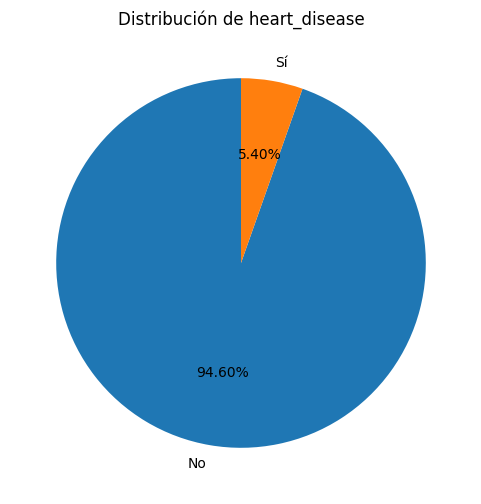

In [28]:
# tarta variable heart_disease:
data = df_stroke["heart_disease"].value_counts()
fig,ax = plt.subplots(1,1,figsize = (6,6))
labels = ["No", "Sí"]
ax.pie(data.values,
        labels= labels,
        autopct='%.2f%%', startangle= 90)
ax.set_title("Distribución de heart_disease")
plt.show();
fig.savefig("src/img/univariante_heart_disease_tarta.png")

Variable *heart_disease*
- Alrededor del 5% tienen alguna enfermedad cardiaca.


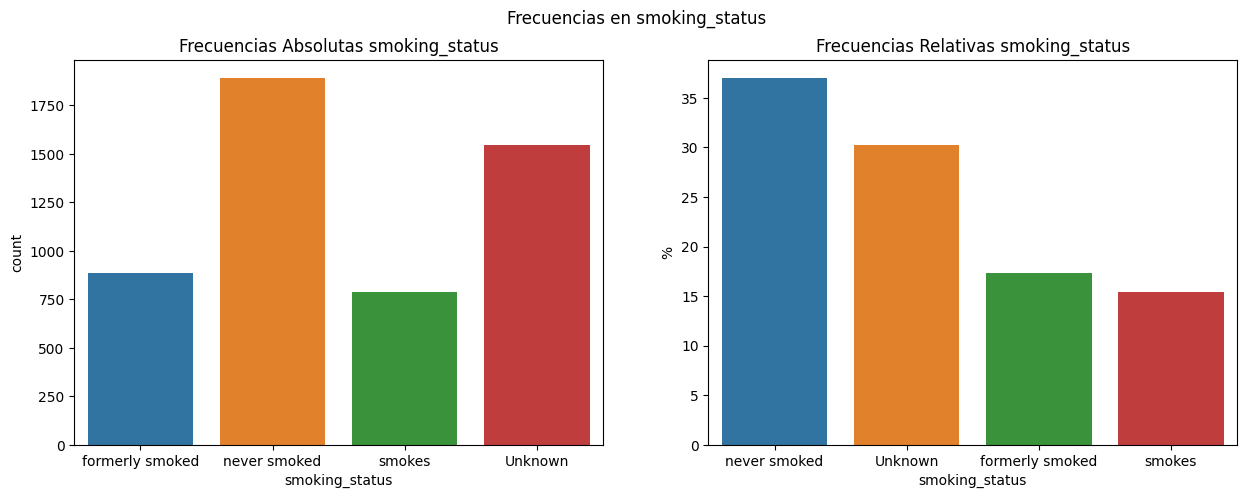

In [29]:
# barras variable smoking_status:
fig,axs = plt.subplots(nrows=1,ncols=2, figsize=(15,5))
fig.suptitle("Frecuencias en smoking_status");
sns.countplot(x="smoking_status", data = df_stroke, ax = axs[0], hue = "smoking_status", legend = False)
axs[0].set_title("Frecuencias Absolutas smoking_status")

valores = df_stroke.smoking_status.value_counts(normalize = True) * 100
sns.barplot(x = valores.index, y = valores.values, hue = valores.index, ax = axs[1])
axs[1].set_title("Frecuencias Relativas smoking_status")
axs[1].set_ylabel("%")
plt.show();
fig.savefig("src/img/univariante_smoking_status_barras.png")

Variable *smoking_status*
- Hay más personas que nunca han fumado, que las que fumaban o no en el momento del estudio. Y hay aproximadamente un 30% que se desconoce. 


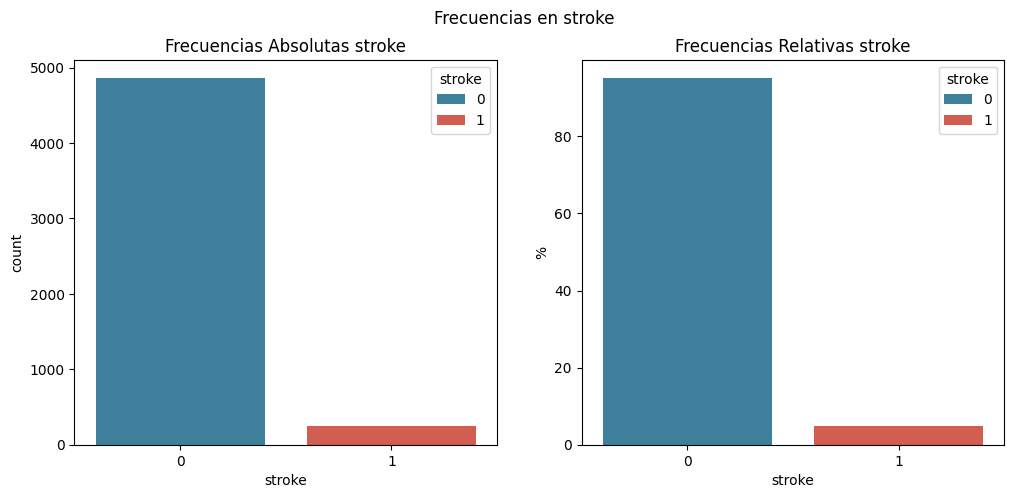

In [30]:
# barras variable stroke:
fig,axs = plt.subplots(nrows=1,ncols=2, figsize=(12,5))
fig.suptitle("Frecuencias en stroke");
palette = ["#2E86AB", "#E74C3C"]
sns.countplot(x="stroke", data = df_stroke, ax = axs[0], hue = "stroke", legend = True, palette=palette)
axs[0].set_title("Frecuencias Absolutas stroke")

valores = df_stroke.stroke.value_counts(normalize = True) * 100
sns.barplot(x = valores.index, y = valores.values, hue = valores.index, ax = axs[1], palette=palette)
axs[1].set_title("Frecuencias Relativas stroke")
axs[1].set_ylabel("%")
plt.show();
fig.savefig("src/img/univariante_stroke_barras.png")

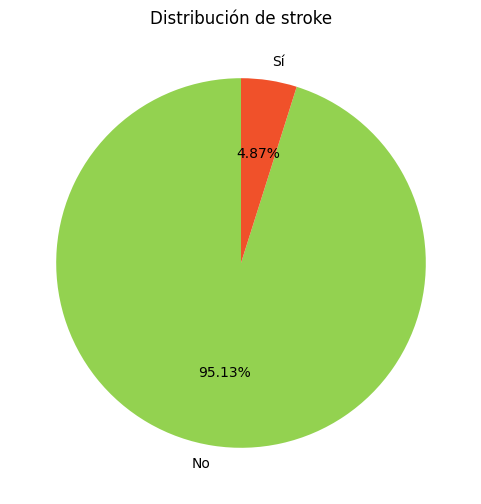

In [31]:
# tarta variable stroke
data = df_stroke["stroke"].value_counts()
fig,ax = plt.subplots(1,1,figsize = (6,6))
labels = ["No", "Sí"]
colors = ["#93D250", "#F0512A"]
ax.pie(data.values,
        labels= labels,
        autopct='%.2f%%', 
        startangle= 90,
        colors=colors)
ax.set_title("Distribución de stroke")
plt.show();
fig.savefig("src/img/univariante_stroke_tarta.png")

Variable *stroke*:
- Menos del 5% han tenido ictus.


### Variables numéricas ###

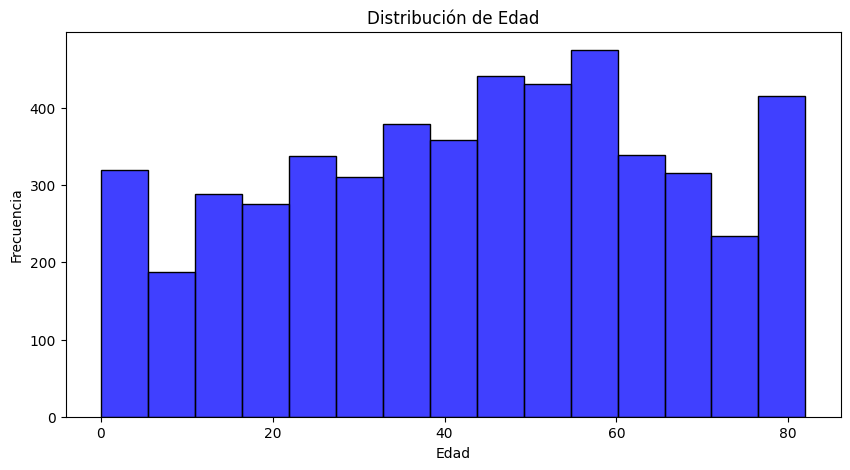

In [32]:
# Histograma variable age:
plt.figure(figsize=(10,5))
sns.histplot(df_stroke["age"], bins=15, kde=False, color="b")
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()
fig.savefig("src/img/univariante_age_histograma.png")

Variable *age*:
- Las edades van desde los 0 años a los 82.

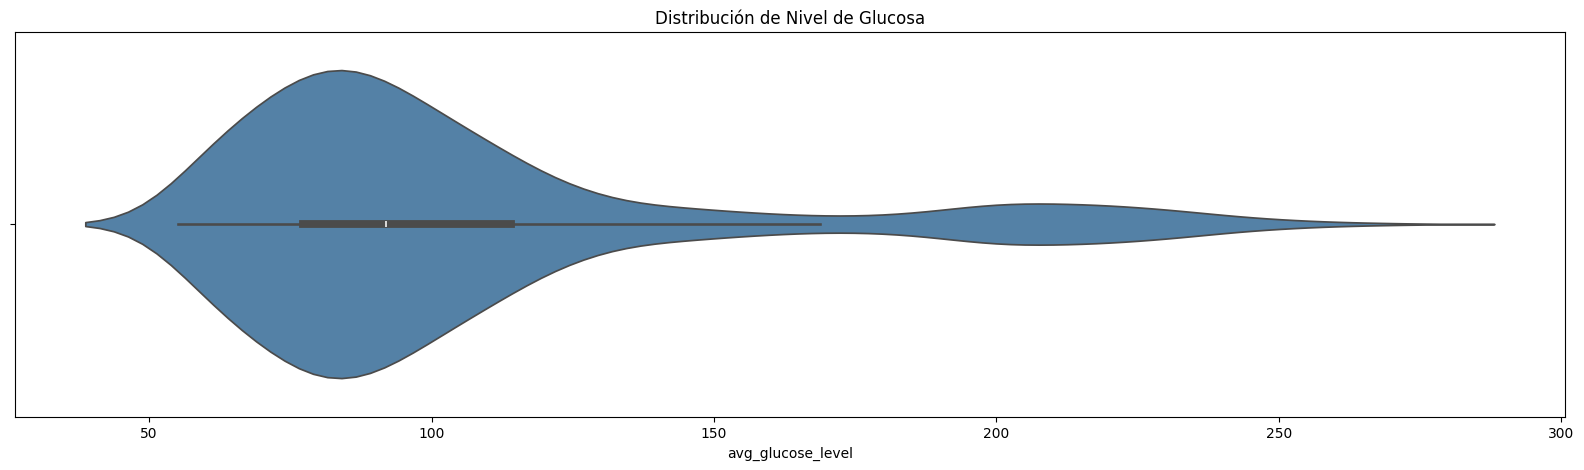

In [33]:
# violin variable avg_glucose_level:
plt.figure(figsize=(20,5))
plt.title("Distribución de Nivel de Glucosa")
sns.violinplot(df_stroke["avg_glucose_level"], color="steelblue", orient="h");
fig.savefig("src/img/univariante_avg_glucose_level_violin.png")

Variable numérica continua *avg_glucose_level*:
- Los valores de glucosa se concentran en su mayoría entre 50 y 150.


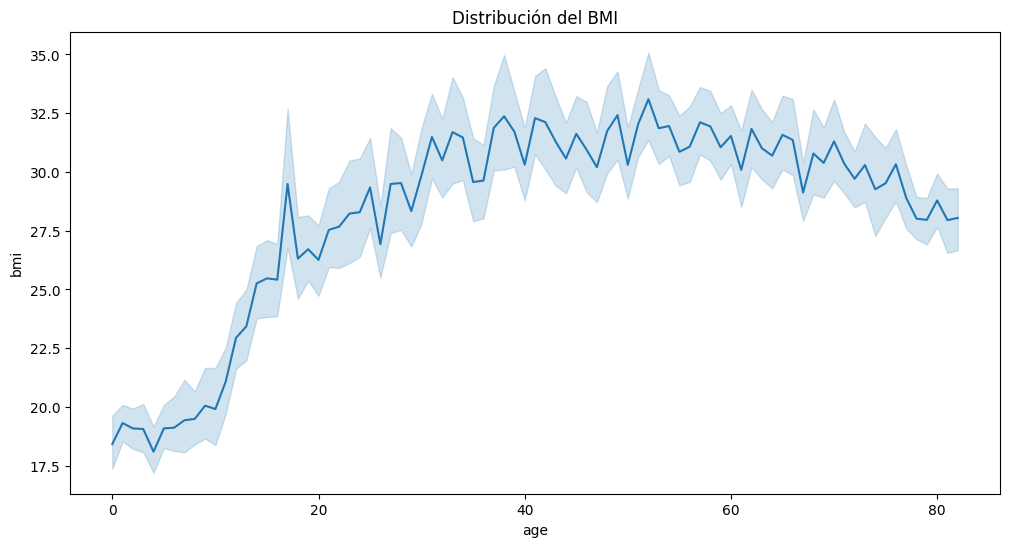

In [34]:
# evolución variable bmi según la variable age:
plt.figure(figsize=(12,6))
plt.title("Distribución del BMI")
sns.lineplot(x=df_stroke.age, y= "bmi", data= df_stroke);
fig.savefig("src/img/univariante_bmi_age_evolucion.png")


Variable numérica continua *bmi*:
- El BMI aumenta entre los 0 y 30 años; es relativamente estable entre los 30 y 60 años, y disminuye ligeramente entre los 60 y 82 años.

## ANÁLISIS BIVARIANTE ##

Comparamos siempre con stroke (variable directora), que es una variable categórica binaria:
- stroke = 0 → no ocurrencia de ictus
- stroke = 1 → sí ocurrencia de ictus

### Edad vs Ictus
- Variables: age (numérica continua) vs stroke (binaria).
- Hipótesis: si la edad es un factor de riesgo, las personas que han sufrido un ictus serán, de media, mayores que las que no. 

In [35]:
sns.set_theme(style='whitegrid')

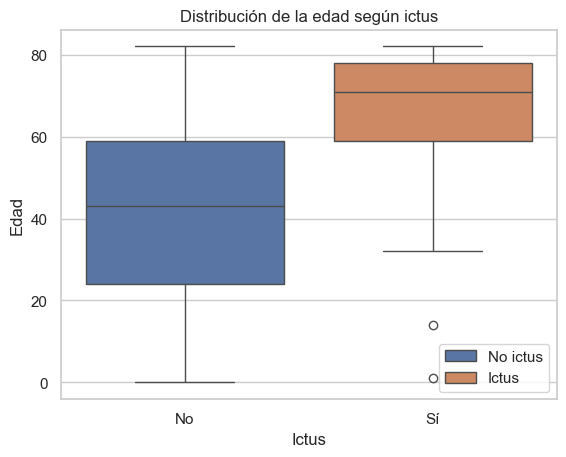

In [36]:
# boxplot
sns.boxplot(
    x='stroke', 
    y='age', 
    hue = 'stroke', 
    data= df_stroke)

plt.xlabel('Ictus')
plt.ylabel('Edad')
plt.title('Distribución de la edad según ictus')
plt.xticks([0, 1], ['No', 'Sí'], rotation=0)
plt.legend(['No ictus', 'Ictus'])
plt.show()
fig.savefig("src/img/bivariante_age_stroke_boxplot.png")

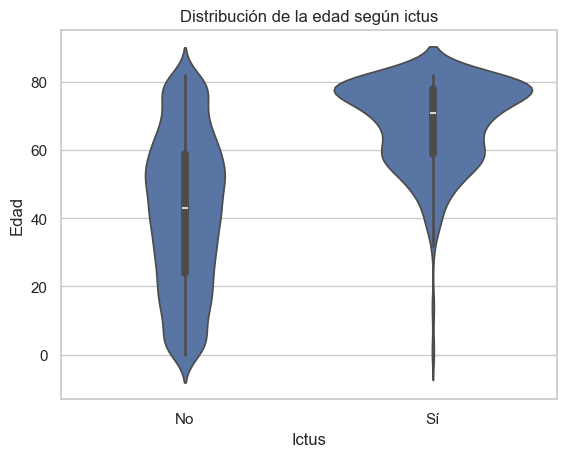

In [37]:
# violin plot
sns.violinplot(
    data=df_stroke,
    x='stroke',
    y='age'
)
plt.xlabel('Ictus')
plt.ylabel('Edad')
plt.title('Distribución de la edad según ictus')
plt.xticks([0, 1], ['No', 'Sí'], rotation=0)
plt.show()
fig.savefig("src/img/bivariante_age_stroke_violin.png")

- Conclusión: los casos de ictus se concentran claramente en personas de mayor edad, lo que confirma que la edad es uno de los principales factores de riesgo.

### Hipertensión vs Ictus
- Variables: hypertension (binaria) vs stroke (binaria).
- Hipótesis: si la hipertensión arterial es un factor de riesgo, el porcentaje de ictus será mayor en hipertensos.

In [38]:
# tabla de contingencia normalizada
tc = pd.crosstab(df_stroke['hypertension'], df_stroke['stroke'], normalize='index') * 100
tc

stroke,0,1
hypertension,,
0,96.032090,3.967910
1,86.746988,13.253012


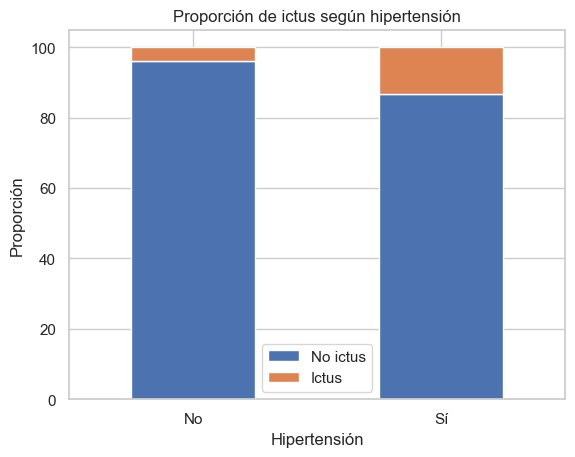

In [39]:
# gráfico de barras apiladas
tc.plot(
    kind='bar',
    stacked=True
)
plt.ylabel('Proporción')
plt.xlabel('Hipertensión')
plt.legend(['No ictus', 'Ictus'])
plt.title('Proporción de ictus según hipertensión')
plt.xticks([0, 1], ['No', 'Sí'], rotation=0)
plt.show()
fig.savefig("src/img/bivariante_stroke_hypertension_barras.png")

- Conclusión: la proporción de ictus es mayor en personas con hipertensión, por lo que podemos afirmar que la hipertensión es un factor de riesgo.

### Glucemia vs Ictus
- Variables: avg_glucose_level (numérica continua) vs stroke (binaria)
- Hipótesis: si los niveles de glucemia son un factor de riesgo para la aparición de ictus, aparecerán más elevados en el grupo con ictus. 

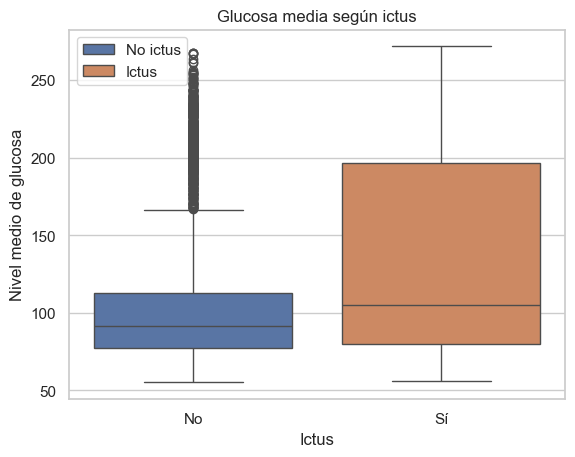

In [40]:
# Boxplot
sns.boxplot(
    x='stroke', 
    y='avg_glucose_level', 
    hue = 'stroke',
    data=df_stroke)

plt.xlabel('Ictus')
plt.ylabel('Nivel medio de glucosa')
plt.title('Glucosa media según ictus')
plt.xticks([0, 1], ['No', 'Sí'], rotation=0)
plt.legend(['No ictus', 'Ictus'])
plt.show()
fig.savefig("src/img/bivariante_stroke_avg_glucose_level_boxplot.png")

- Conclusión: los niveles medios de glucosa son más elevados en el grupo con ictus, lo que sugiere un papel como factor de riesgo de esta alteración endocrina. 

### Índice de masa corporal vs Stroke
- Variables: bmi (numérica continua) vs stroke (binaria)
- Hipótesis: si el IMC alto es un factor de riesgo de ictus, éste será mayor en el grupo de afectados. 

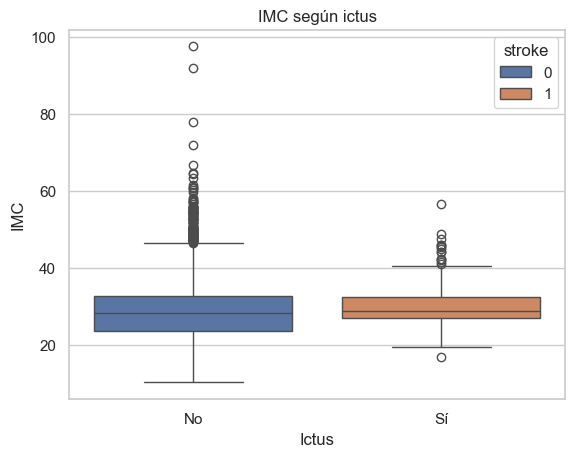

In [41]:
# Boxplot
sns.boxplot(
    x='stroke', 
    y='bmi', 
    hue = 'stroke', 
    data=df_stroke)

plt.xlabel('Ictus')
plt.ylabel('IMC')
plt.title('IMC según ictus')
plt.xticks([0, 1], ['No', 'Sí'], rotation=0)
plt.show()
fig.savefig("src/img/bivariante_stroke_bmi_boxplot.png")

- Conclusión: la relación entre IMC e ictus parece ser débil, sin clara separación entre grupos, en comparación con otras variables analizadas anteriormente, como la edad o la hipertensión. 

## ANÁLISIS MULTIVARIANTE ##

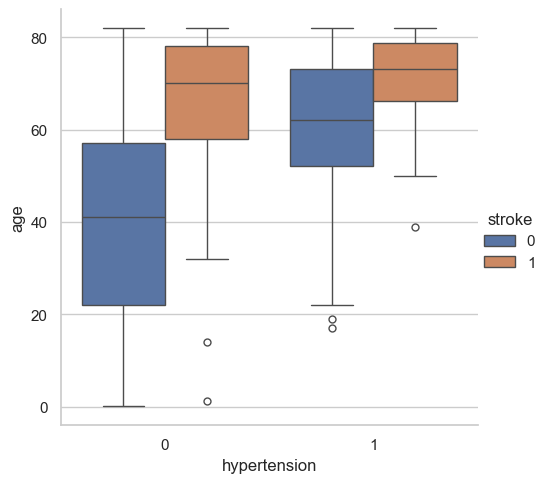

In [42]:
sns.catplot(
    data=df_stroke_prediction,
    x="hypertension",
    y="age",
    hue="stroke",
    kind="box"
)
fig.savefig("src/img/multivariante_stroke_hypertension_age_boxplot.png");

### Conclusiones
- En ambos grupos de hipertensión (0 y 1), los individuos que han sufrido un ictus (stroke = 1) presentan una edad media superior a los que no lo han sufrido (stroke = 0).
- La diferencia de edad entre personas con y sin ictus es más pronunciada en el grupo con hipertensión, lo que sugiere una posible interacción entre edad e hipertensión en el riesgo de ictus.
- La dispersión de edad (rango intercuartílico) es mayor en los grupos sin ictus, especialmente entre los no hipertensos, lo que indica mayor variabilidad de edad en ese segmento.
- Los grupos con ictus muestran distribuciones más concentradas en edades avanzadas, lo que refuerza la hipótesis de que el ictus se asocia con edad elevada.
- La presencia de outliers en los grupos sin ictus sugiere que hay individuos jóvenes sin hipertensión que también forman parte del conjunto, lo cual podría ser relevante para análisis de prevención.


c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette usin

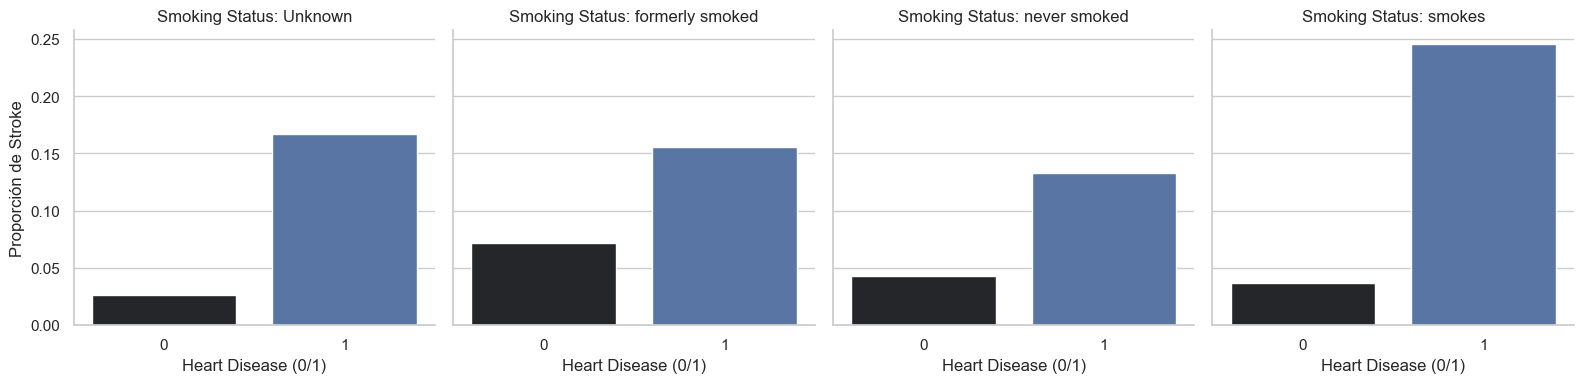

In [43]:
# Calcular proporciones de stroke por grupo
df_grouped = (
    df_stroke_prediction.groupby(["smoking_status", "heart_disease"])["stroke"]
      .mean()
      .reset_index()
)

# Crear FacetGrid por categoría de fumador
g = sns.FacetGrid(df_grouped, col="smoking_status", height=4, sharey=True)

# Barplot sin palette (evita warnings)
g.map_dataframe(
    sns.barplot,
    x="heart_disease",
    y="stroke",
    hue="heart_disease",
    dodge=False,
    legend=False
)

# Etiquetas y títulos
g.set_axis_labels("Heart Disease (0/1)", "Proporción de Stroke")
g.set_titles("Smoking Status: {col_name}")
fig.savefig("src/img/multivariante_stroke_heart_disease_smoking_status.png");

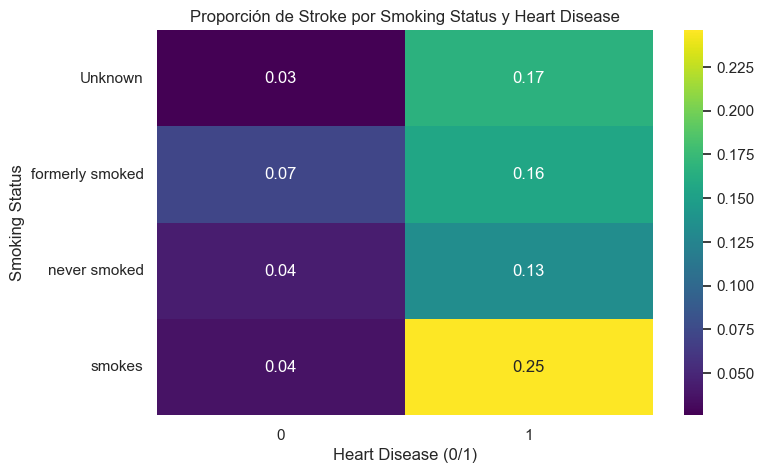

In [44]:

# 1. Calcular proporciones de stroke por grupo
df_grouped = (
    df_stroke_prediction.groupby(["smoking_status", "heart_disease"])["stroke"]
      .mean()
      .reset_index()
)

# 2. Pivotar para crear la matriz del heatmap
heatmap_data = df_grouped.pivot(
    index="smoking_status",
    columns="heart_disease",
    values="stroke"
)

# 3. Dibujar el heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Proporción de Stroke por Smoking Status y Heart Disease")
plt.xlabel("Heart Disease (0/1)")
plt.ylabel("Smoking Status")
plt.show()
fig.savefig("src/img/multivariante_stroke_heart_disease_smoking_status_mapa_calor.png");

### Conclusiones:
- En todos los grupos de fumadores, la proporción de stroke es mayor en individuos con enfermedad cardíaca (heart_disease = 1) que en aquellos sin ella (heart_disease = 0), lo que indica una asociación consistente entre enfermedad cardíaca e ictus.
- El grupo "smokes" con enfermedad cardíaca presenta la proporción más alta de stroke (0.25), lo que sugiere que fumar podría aumentar el riesgo asociado a la cardiopatía.
- En el grupo "never smoked", la proporción de stroke es relativamente baja incluso en presencia de enfermedad cardíaca (0.13), lo que podría indicar un efecto protector del no consumo de tabaco.
- El grupo "formerly smoked" muestra una proporción intermedia de stroke, lo que sugiere que el riesgo disminuye tras dejar de fumar, aunque no se iguala al de quienes nunca fumaron.
- El grupo "unknown" presenta una proporción elevada de stroke en presencia de enfermedad cardíaca (0.17), pero su interpretación clínica es limitada debido a la ambigüedad de la categoría.
- La consistencia del patrón en ambos gráficos (barplot y heatmap) refuerza la validez de la relación observada entre smoking status, heart disease y stroke, y justifica el uso de modelos multivariantes para cuantificar el riesgo


In [45]:
le = LabelEncoder()
for col in df_stroke.select_dtypes(include='object').columns:
    df_stroke[col] = le.fit_transform(df_stroke[col])

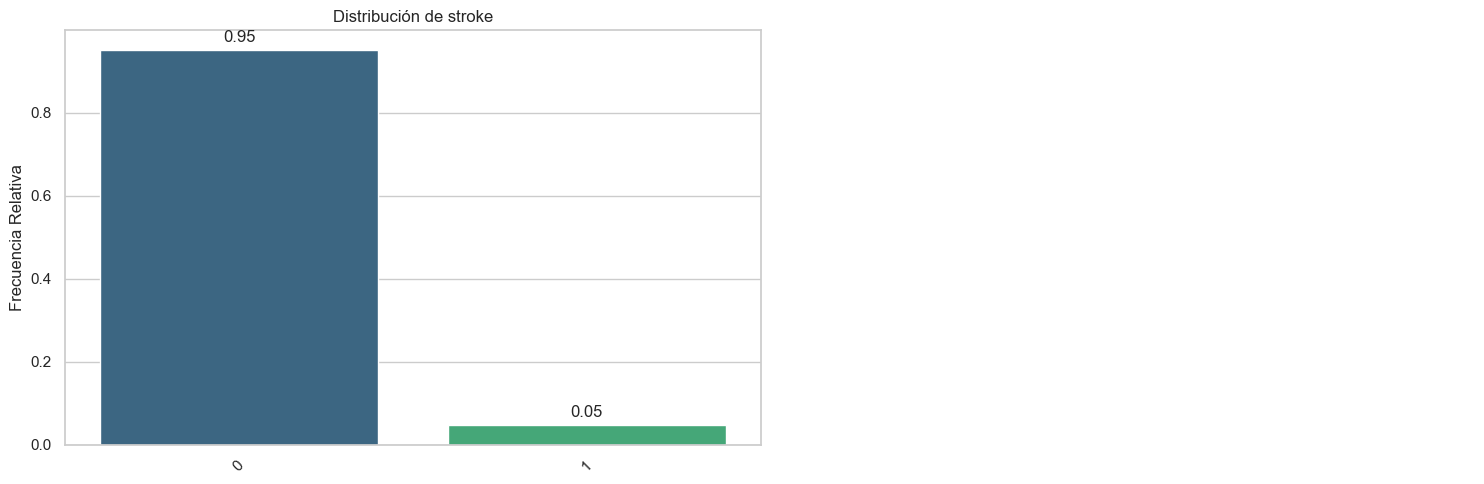

In [46]:
bt.pinta_distribucion_categoricas(df_stroke, ["stroke"], relativa= True, mostrar_valores= True)

In [47]:
target  = "stroke"

# Train y Test #

In [48]:
train_set, test_set = train_test_split(df_stroke, test_size= 0.2, random_state= 42)

### MiniEda ###

In [49]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4088 entries, 802 to 860
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4088 non-null   int64  
 1   age                4088 non-null   int64  
 2   hypertension       4088 non-null   int64  
 3   heart_disease      4088 non-null   int64  
 4   ever_married       4088 non-null   int64  
 5   work_type          4088 non-null   int64  
 6   Residence_type     4088 non-null   int64  
 7   avg_glucose_level  4088 non-null   float64
 8   bmi                4088 non-null   float64
 9   smoking_status     4088 non-null   int64  
 10  stroke             4088 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 383.2 KB


In [50]:
features_cat = train_set.select_dtypes(include = "int").columns.to_list()

if target in features_cat:
    features_cat.remove(target)
    
features_cat

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status']

In [51]:
features_num = [col for col in train_set.columns if col not in features_cat and col != target]

features_num

['avg_glucose_level', 'bmi']

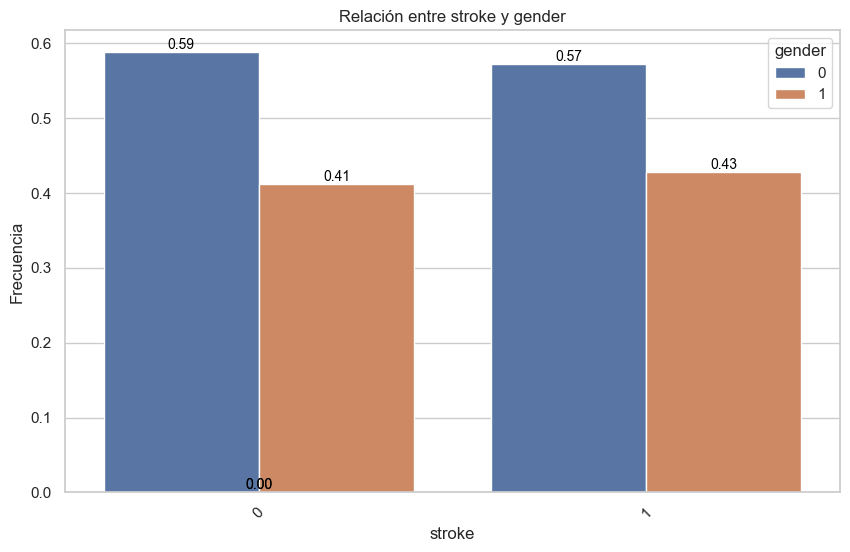

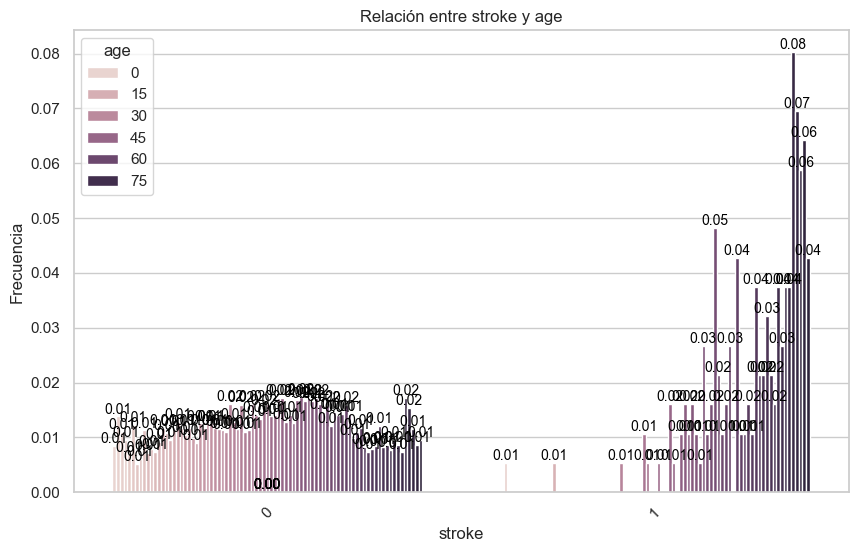

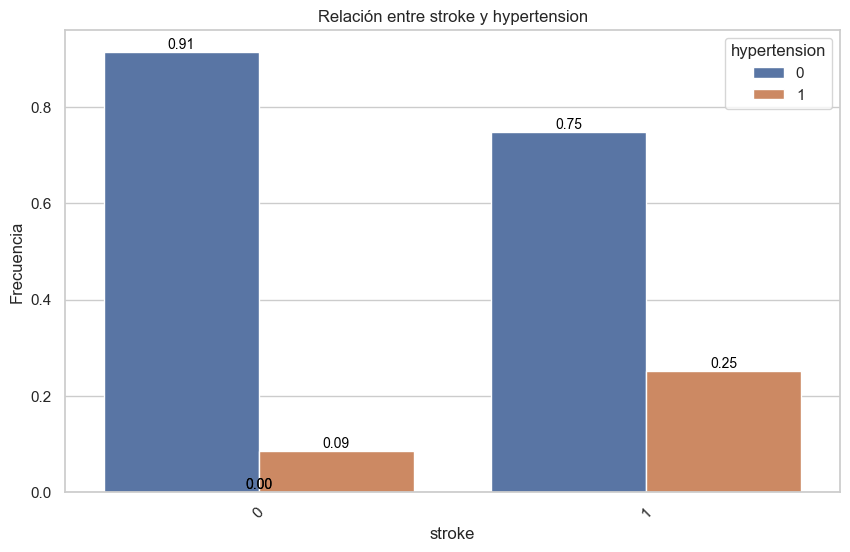

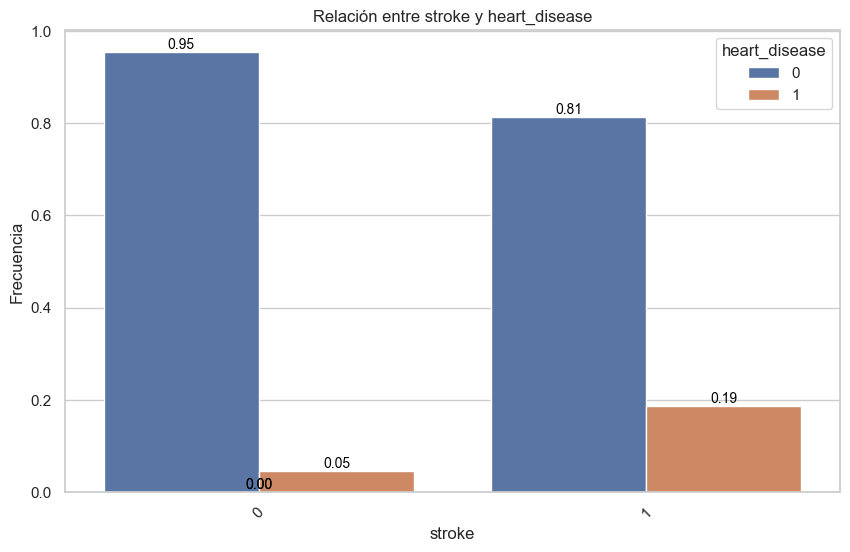

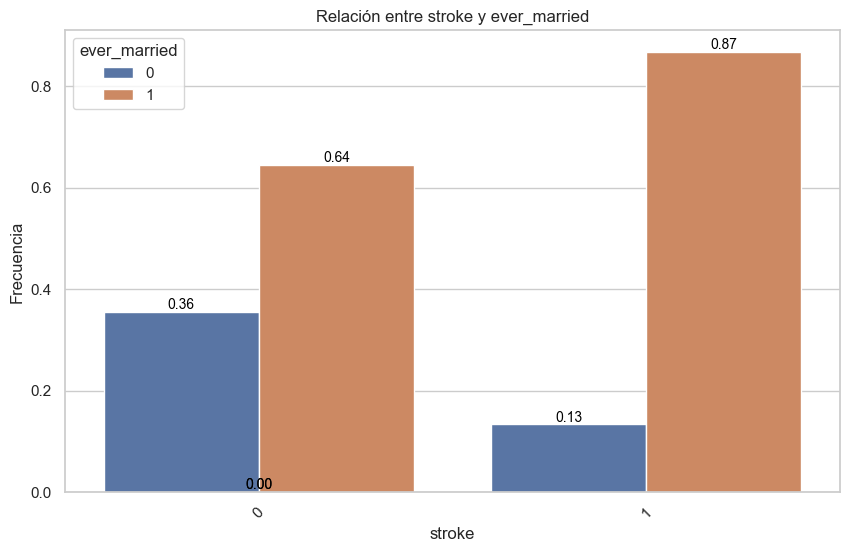

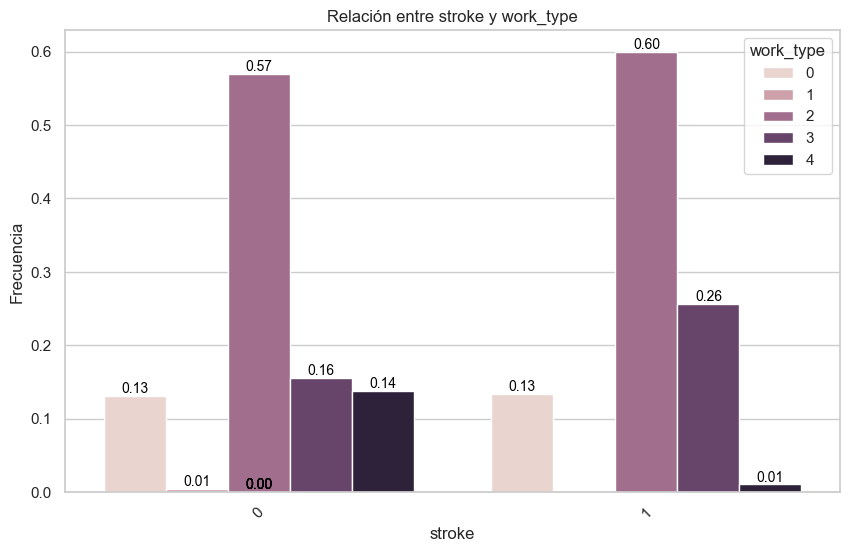

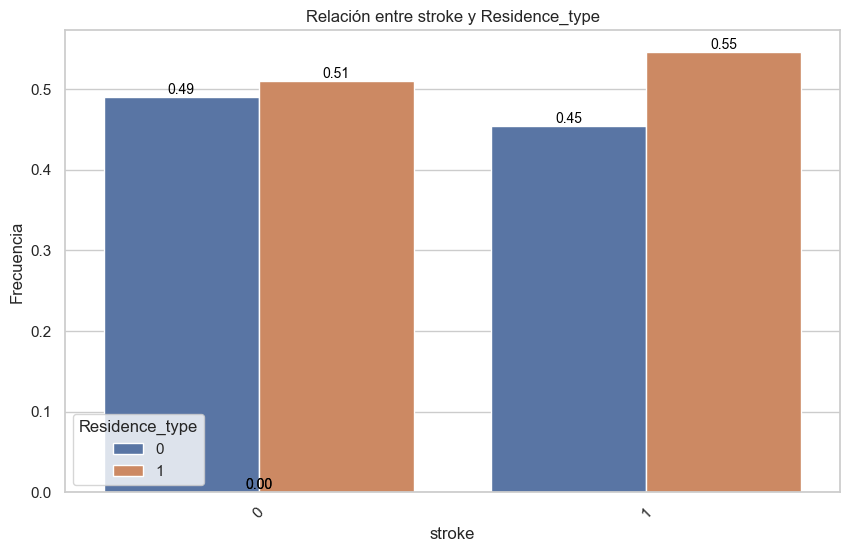

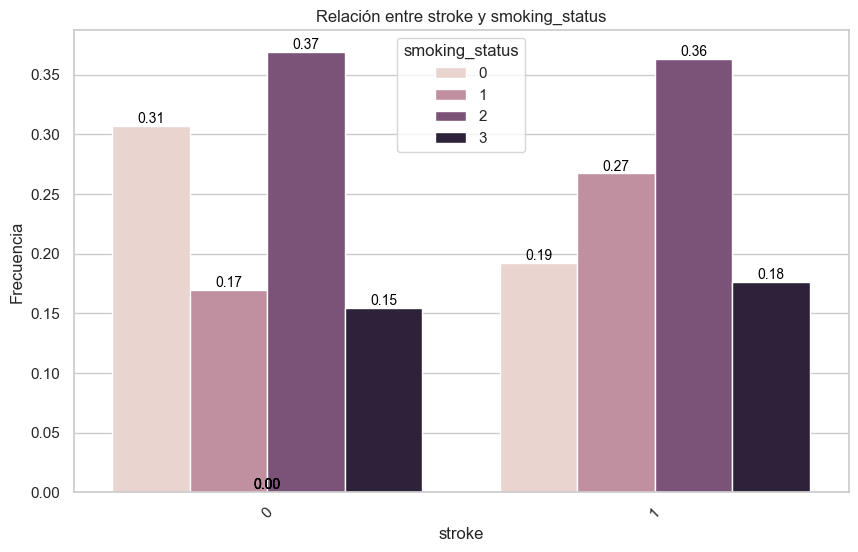

In [52]:
for col in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, col, relative_freq= True, show_values= True)

### Analizamos Numéricas ###

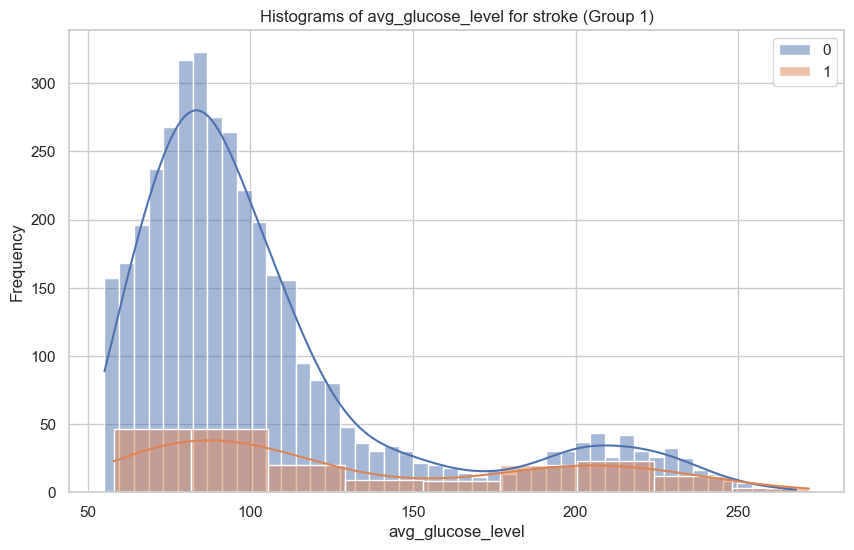

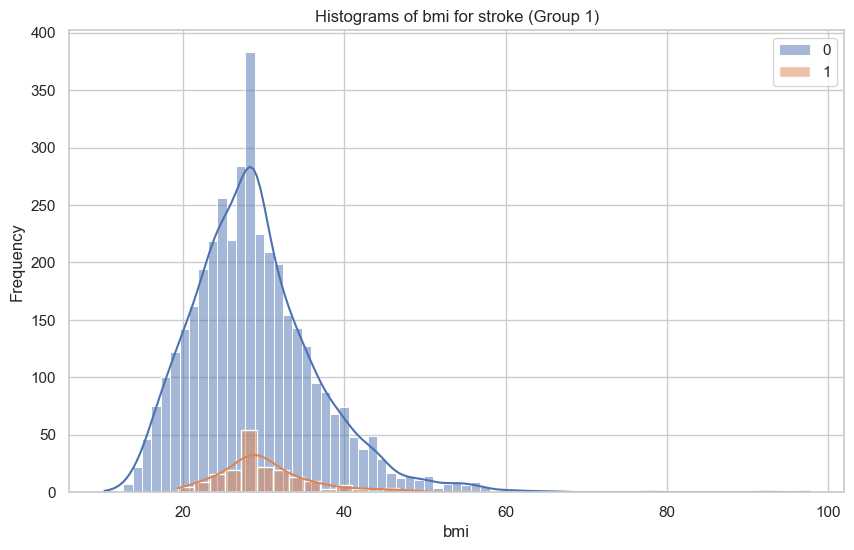

In [53]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 2)

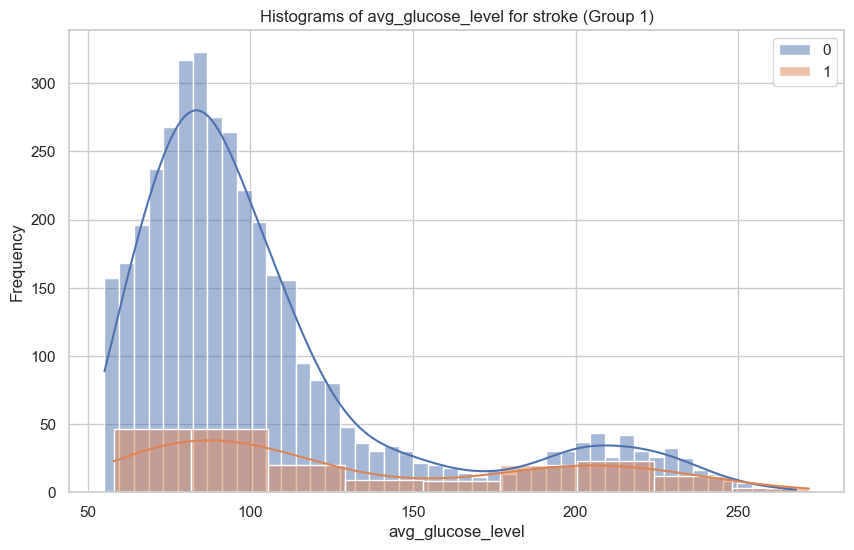

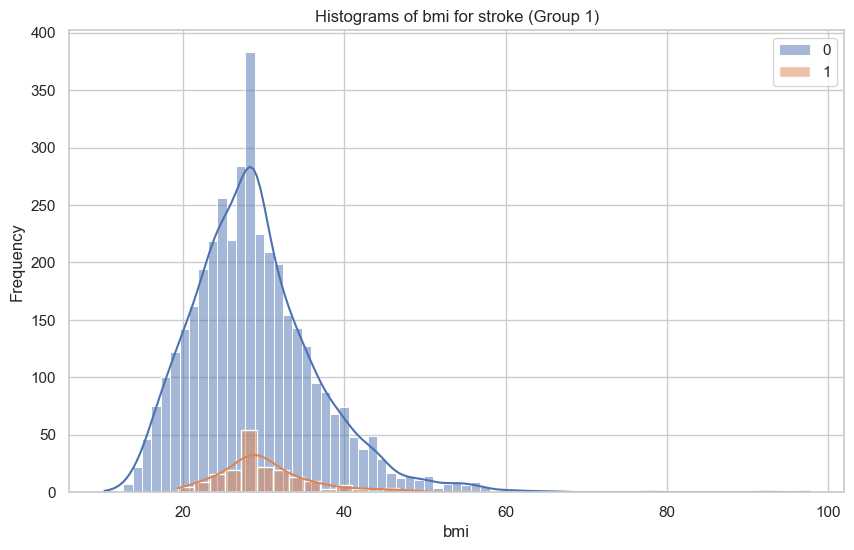

In [54]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 2)

### Tratamiento ###

In [55]:
train_set[features_cat].nunique()

gender             2
age               83
hypertension       2
heart_disease      2
ever_married       2
work_type          5
Residence_type     2
smoking_status     4
dtype: int64

In [56]:
features_cat_sel = features_cat.copy()

In [57]:
train_set["hypertension"] == "1"

802     False
3927    False
2337    False
3910    False
1886    False
        ...  
4426    False
466     False
3092    False
3772    False
860     False
Name: hypertension, Length: 4088, dtype: bool

In [58]:
train_set["hypertension"] = train_set["hypertension"] == "1"
train_set["heart_disease"] = train_set["heart_disease"] == "1"

test_set["hypertension"] = test_set["hypertension"] == "1" 
test_set["heart_disease"] = test_set["heart_disease"] == "1"

features_cat.remove("hypertension") 
features_cat.remove("heart_disease")

In [59]:
train_set = pd.get_dummies(train_set, columns = features_cat, dtype = int)
test_set = pd.get_dummies(test_set, columns = features_cat, dtype = int)

In [60]:
train_set.shape

(4088, 103)

In [61]:
test_set.shape

(1022, 103)

In [62]:
train_set.columns[~train_set.columns.isin(test_set.columns)]

Index([], dtype='object')

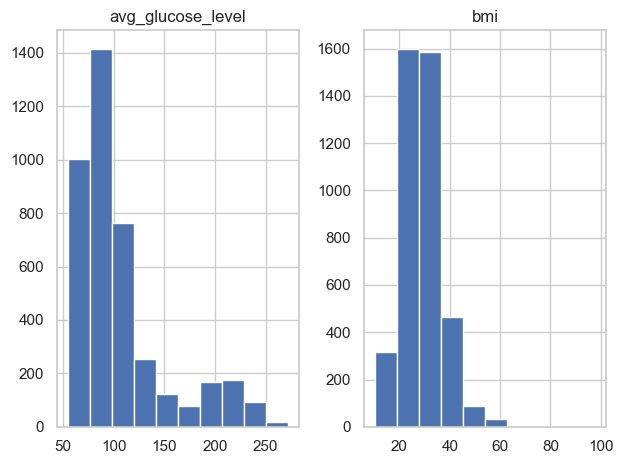

In [63]:
train_set[features_num].hist()
plt.tight_layout()

In [64]:
features_num

['avg_glucose_level', 'bmi']

In [65]:
features_cat_sel

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status']

In [66]:
train_set.columns

Index(['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke',
       'gender_0', 'gender_1', 'age_0', 'age_1', 'age_2',
       ...
       'work_type_1', 'work_type_2', 'work_type_3', 'work_type_4',
       'Residence_type_0', 'Residence_type_1', 'smoking_status_0',
       'smoking_status_1', 'smoking_status_2', 'smoking_status_3'],
      dtype='object', length=103)

In [67]:
features_encoded_cat_sel = []

for col in features_cat_sel:
    defintive_col = [col_2 for col_2 in train_set.columns if col_2.startswith(col)]
    features_encoded_cat_sel += defintive_col

features_encoded_cat_sel

['gender_0',
 'gender_1',
 'age_0',
 'age_1',
 'age_2',
 'age_3',
 'age_4',
 'age_5',
 'age_6',
 'age_7',
 'age_8',
 'age_9',
 'age_10',
 'age_11',
 'age_12',
 'age_13',
 'age_14',
 'age_15',
 'age_16',
 'age_17',
 'age_18',
 'age_19',
 'age_20',
 'age_21',
 'age_22',
 'age_23',
 'age_24',
 'age_25',
 'age_26',
 'age_27',
 'age_28',
 'age_29',
 'age_30',
 'age_31',
 'age_32',
 'age_33',
 'age_34',
 'age_35',
 'age_36',
 'age_37',
 'age_38',
 'age_39',
 'age_40',
 'age_41',
 'age_42',
 'age_43',
 'age_44',
 'age_45',
 'age_46',
 'age_47',
 'age_48',
 'age_49',
 'age_50',
 'age_51',
 'age_52',
 'age_53',
 'age_54',
 'age_55',
 'age_56',
 'age_57',
 'age_58',
 'age_59',
 'age_60',
 'age_61',
 'age_62',
 'age_63',
 'age_64',
 'age_65',
 'age_66',
 'age_67',
 'age_68',
 'age_69',
 'age_70',
 'age_71',
 'age_72',
 'age_73',
 'age_74',
 'age_75',
 'age_76',
 'age_77',
 'age_78',
 'age_79',
 'age_80',
 'age_81',
 'age_82',
 'hypertension',
 'heart_disease',
 'ever_married_0',
 'ever_married_1'

In [68]:
X_train = train_set[features_encoded_cat_sel + features_num].copy()
X_train_scaled = train_set[features_encoded_cat_sel + features_num].copy()
y_train = train_set[target]

X_test = test_set[features_encoded_cat_sel + features_num].copy()
X_test_scaled = test_set[features_encoded_cat_sel + features_num].copy()
y_test = test_set[target]

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_clf = LogisticRegression(max_iter = 1000)
tree_clf = DecisionTreeClassifier(random_state = 42) 

lr_clf.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
print(classification_report(y_train, lr_clf.predict(X_train_scaled)))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3901
           1       0.00      0.00      0.00       187

    accuracy                           0.95      4088
   macro avg       0.48      0.50      0.49      4088
weighted avg       0.91      0.95      0.93      4088



c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [72]:
print(classification_report(y_test, lr_clf.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [73]:
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [74]:
print(classification_report(y_train, tree_clf.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3901
           1       1.00      1.00      1.00       187

    accuracy                           1.00      4088
   macro avg       1.00      1.00      1.00      4088
weighted avg       1.00      1.00      1.00      4088



In [75]:
print(classification_report(y_test, tree_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       960
           1       0.14      0.08      0.10        62

    accuracy                           0.91      1022
   macro avg       0.54      0.52      0.53      1022
weighted avg       0.89      0.91      0.90      1022



In [76]:
from sklearn.model_selection import GridSearchCV 

param_grid = {
    "max_depth": [1,2,8,10],
    "min_samples_leaf": [1,10,20,100],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None]
}

tree_clf = DecisionTreeClassifier(random_state= 42)

tree_grid = GridSearchCV(tree_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring = "balanced_accuracy") # Depende del impacto en el problema de negocio

tree_grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [77]:
y_pred = tree_grid.best_estimator_.predict(X_train)

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.57      0.73      3901
           1       0.09      0.84      0.16       187

    accuracy                           0.59      4088
   macro avg       0.54      0.71      0.44      4088
weighted avg       0.95      0.59      0.70      4088



In [78]:
y_pred = tree_grid.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.61      0.75       960
           1       0.10      0.69      0.18        62

    accuracy                           0.62      1022
   macro avg       0.54      0.65      0.46      1022
weighted avg       0.92      0.62      0.71      1022



In [79]:
df_feat_importance = pd.DataFrame({"features": tree_grid.best_estimator_.feature_names_in_, "importancia": tree_grid.best_estimator_.feature_importances_}).sort_values("importancia",ascending=False)
df_feat_importance

,features,importancia
100,avg_glucose_level,0.476821
101,bmi,0.198864
93,work_type_4,0.153292
92,work_type_3,0.055802
88,ever_married_1,0.055453
...,...,...
94,Residence_type_0,0.000000
97,smoking_status_1,0.000000
96,smoking_status_0,0.000000
95,Residence_type_1,0.000000
